# Step 1 - Import libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose your assets

In [2]:
tickers = ["SPY", "QQQ", "AAPL", "MSFT"]

data = yf.download(tickers, start = "2020-01-01")['Close']

data.isnull().sum()
data.dropna(inplace = True)

data.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,MSFT,QQQ,SPY
Date,,,,
2020-01-02,72.333870,151.829529,208.317566,296.888092
2020-01-03,71.630646,149.938965,206.409409,294.640045
2020-01-06,72.201424,150.326569,207.739304,295.764099
2020-01-07,71.861847,148.955933,207.710403,294.932526
2020-01-08,73.017845,151.328568,209.271622,296.504425


# Compute Returns

In [3]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,MSFT,QQQ,SPY
Date,,,,
2020-01-03,-0.009722,-0.012452,-0.009160,-0.007572
2020-01-06,0.007968,0.002585,0.006443,0.003815
2020-01-07,-0.004703,-0.009118,-0.000139,-0.002812
2020-01-08,0.016086,0.015928,0.007516,0.005330
2020-01-09,0.021240,0.012493,0.008473,0.006780


In [4]:
compounded_return = (1 + returns).prod() ** (252/len(returns)) - 1
compounded_return.head()

Ticker
AAPL    0.249521
MSFT    0.168438
QQQ     0.212472
SPY     0.152972
dtype: float64

# Basic Metrics

In [5]:
mean_returns = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    "Annual Return": mean_returns,
    "Volatility": volatility
})

summary


,Annual Return,Volatility
Ticker,,
AAPL,0.271815,0.313467
MSFT,0.200141,0.298063
QQQ,0.223906,0.249518
SPY,0.163139,0.203511


# Sharpe Ratio

In [6]:

risk_free_rate = 0.02  # 2% assumption

sharpe = (mean_returns - risk_free_rate) / volatility

summary["Sharpe Ratio"] = sharpe
summary


,Annual Return,Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.271815,0.313467,0.803322
MSFT,0.200141,0.298063,0.604371
QQQ,0.223906,0.249518,0.817201
SPY,0.163139,0.203511,0.703350


# Growth Comparison

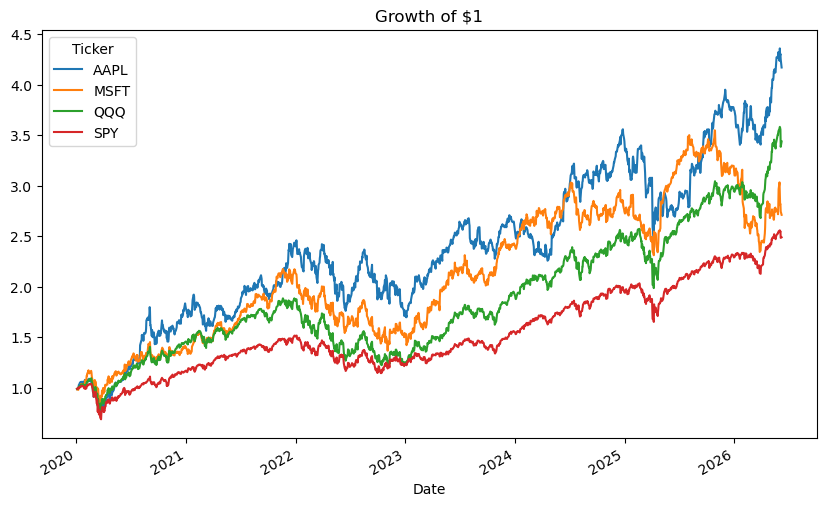

In [7]:

cumulative = (1 + returns).cumprod()

cumulative.plot(figsize=(10,6), title="Growth of $1")
plt.show()


# Drawdowns

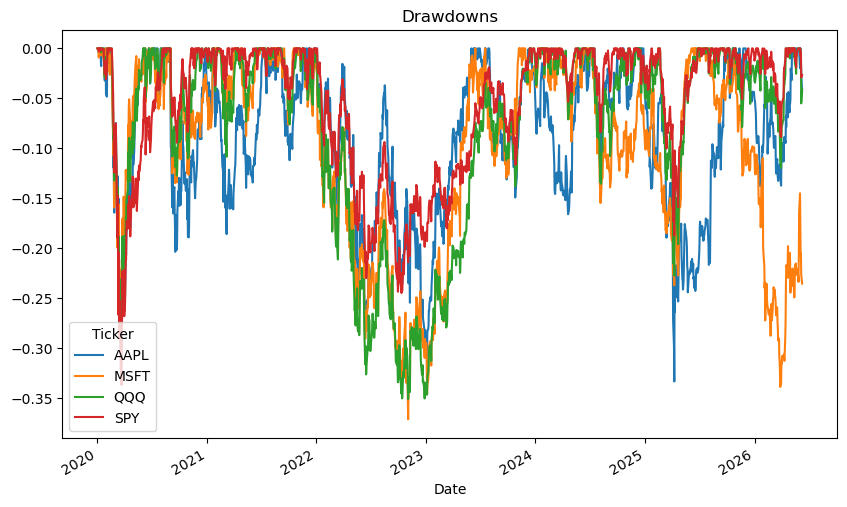

In [8]:

rolling_max = cumulative.cummax()
drawdown = cumulative / rolling_max - 1

drawdown.plot(figsize=(10,6), title="Drawdowns")
plt.show()
